# 5. Proyecciones de la red

Se parte de la red bipartita autor-video construida en la sección 4 (351 nodos: 332 autores y 19 videos; 343 aristas). Una proyección colapsa uno de los dos conjuntos de nodos: se conserva solo un tipo de nodo y se conectan entre sí aquellos que compartían un vecino en el otro conjunto.

Toda proyección pierde información y **crea** aristas que no estaban en los datos: si un video recibe comentarios de *k* autores distintos, la proyección autor-autor genera automáticamente las *k(k-1)/2* aristas de ese grupo. Esto se tiene presente al interpretar densidad y transitividad en la sección 6.

In [1]:
from itertools import combinations
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from networkx.algorithms import bipartite

DATA_DIR = Path("data") if Path("data").exists() else Path("../data")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

comments = pd.read_csv(DATA_DIR / "comments_procesado.csv", encoding="utf-8-sig")
videos = pd.read_csv(DATA_DIR / "videos_procesado.csv", encoding="utf-8-sig")

autores_ids = list(comments["author_channel_id"].unique())
videos_ids = list(comments["video_id"].unique())
titulo = videos.set_index("video_id")["title"].to_dict()
canal = videos.set_index("video_id")["channel_name"].to_dict()
categoria = videos.set_index("video_id")["category"].to_dict()
aristas = comments.groupby(["author_channel_id", "video_id"]).size().reset_index(name="peso")

B = nx.Graph()
B.add_nodes_from(autores_ids, tipo="autor")
B.add_nodes_from(videos_ids, tipo="video")
for _, row in aristas.iterrows():
    B.add_edge(row["author_channel_id"], row["video_id"], weight=row["peso"])

print(f"Red bipartita: {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")

Red bipartita: 351 nodos, 343 aristas


### 5.1 Proyección autor-autor

**Definición.** Dos autores se conectan si comentaron en al menos un video en común. El **peso** de la arista es el número de videos que ambos comentaron.

Se usa `bipartite.weighted_projected_graph`, cuyo peso es exactamente el número de vecinos compartidos en la red bipartita, es decir, el número de videos compartidos.

In [2]:
AA = bipartite.weighted_projected_graph(B, autores_ids)

pesos_aa = pd.Series([d['weight'] for _, _, d in AA.edges(data=True)])
print(f'Proyección autor-autor: {AA.number_of_nodes()} nodos, {AA.number_of_edges()} aristas')
print('\nDistribución del peso (número de videos compartidos):')
print(pesos_aa.value_counts().sort_index().rename('n_aristas').to_string())

# Verificación del artefacto de proyección: cada video con k autores aporta k(k-1)/2 aristas.
autores_por_video = comments.groupby('video_id')['author_channel_id'].nunique()
aristas_generadas = int((autores_por_video * (autores_por_video - 1) / 2).sum())
print(f'\nAristas que generarían los 19 videos si no hubiera solapamiento: {aristas_generadas}')
print(f'Aristas observadas: {AA.number_of_edges()} '
      f'(diferencia {aristas_generadas - AA.number_of_edges()} = pares contados dos veces)')

mayor = int(autores_por_video.max())
print(f'Solo el video más comentado ({mayor} autores) aporta {mayor * (mayor - 1) // 2} aristas '
      f'({mayor * (mayor - 1) / 2 / AA.number_of_edges():.1%} del total).')

pares_fuertes = [(u, v, d['weight']) for u, v, d in AA.edges(data=True) if d['weight'] > 1]
print(f'\nPares de autores que comparten más de un video: {len(pares_fuertes)}')

Proyección autor-autor: 332 nodos, 10732 aristas

Distribución del peso (número de videos compartidos):
1    10730
2        2

Aristas que generarían los 19 videos si no hubiera solapamiento: 10734
Aristas observadas: 10732 (diferencia 2 = pares contados dos veces)
Solo el video más comentado (128 autores) aporta 8128 aristas (75.7% del total).

Pares de autores que comparten más de un video: 2


In [3]:
nombre_autor = comments.drop_duplicates('author_channel_id').set_index('author_channel_id')['author_name']
for u, v, w in pares_fuertes:
    print(f'peso {w}: {nombre_autor[u]}  <->  {nombre_autor[v]}')

peso 2: @hashojea7348  <->  @Alejandro00710
peso 2: @inge_vergueta  <->  @Jel.Awesh.M


Prácticamente todas las aristas (10,730 de 10,732) tienen peso 1: reflejan un único video compartido. Solo 2 pares de autores coincidieron en dos videos distintos. Es decir, el peso casi no discrimina: en esta muestra la co-participación repetida es un evento raro.

El volumen de aristas tampoco indica una red densa de interacción. Las 10,732 aristas son casi enteramente el producto mecánico de agrupar por video: el video más comentado, con 128 autores, aporta por sí solo 8,128 aristas (75.7 % del total). Sin ese video la proyección sería mucho más pequeña.

### 5.2 Proyección video-video

**Definición.** Dos videos se conectan si comparten al menos un autor de comentarios. El **peso** de la arista es el número de autores compartidos.

In [4]:
VV = bipartite.weighted_projected_graph(B, videos_ids)

print(f'Proyección video-video: {VV.number_of_nodes()} nodos, {VV.number_of_edges()} aristas')
print('\nAristas (peso = número de autores compartidos):')
tabla_vv = pd.DataFrame(
    [(titulo.get(u, u), titulo.get(v, v), d['weight']) for u, v, d in VV.edges(data=True)],
    columns=['video_a', 'video_b', 'autores_compartidos'],
).sort_values('autores_compartidos', ascending=False)
tabla_vv['video_a'] = tabla_vv['video_a'].str.slice(0, 42)
tabla_vv['video_b'] = tabla_vv['video_b'].str.slice(0, 42)
print(tabla_vv.to_string(index=False))

Proyección video-video: 19 nodos, 11 aristas

Aristas (peso = número de autores compartidos):
                                   video_a                                    video_b  autores_compartidos
La cooptación de Walter Mazariegos en la U                  Qué rico come tu diputado                    2
            Arroz con pollo a la MONOPOLIO            Internet: escoger el menos malo                    2
La cooptación de Walter Mazariegos en la U Capturan a ladrón que había quedado grabad                    1
La cooptación de Walter Mazariegos en la U            Internet: escoger el menos malo                    1
Capturan a presuntos delincuentes disfraza Inician los trabajos de recuperación del P                    1
            Arroz con pollo a la MONOPOLIO    Caminar en una ciudad hecha para carros                    1
                 Qué rico come tu diputado Conferencia de Prensa del Gobierno de Guat                    1
                 Qué rico come tu diputado        

In [5]:
# Videos sin ningún autor compartido con el resto (grado 0 en la proyección).
videos_aislados = [v for v in videos_ids if VV.degree(v) == 0]
canal = videos.set_index('video_id')['channel_name'].to_dict()

print(f'Videos sin audiencia compartida: {len(videos_aislados)} de {len(videos_ids)}\n')
for v in videos_aislados:
    print(f'  - {titulo.get(v, v)[:55]:<57} ({canal.get(v, "?")})')

Videos sin audiencia compartida: 9 de 19

  - EE.UU. envía a mexicanos deportados a Guatemala antes d   (Noticias Telemundo)
  - Plan 2032 Ciudad de Guatemala                             (Municipalidad de Guatemala)
  - I’x K’at: el primer equipo guatemalteco de pelota maya,   (Quorum)
  - Cruzando la ciudad a puro Transmetro                      (Quorum)
  - Edén por Salud: empleo inclusivo para personas con disc   (Quorum)
  - 10 Preguntas a un año del Paro Nacional                   (Quorum)
  - Noticiero en Directo 1 pm, 28 de Agosto de 2026           (Noticiero Guatevisión 13 Hrs.)
  - SHAI WA: la vecina queer de Casa Presidencial             (Quorum)
  - ¿Quiénes pagan más en Centroamérica?                      (Quorum)


De 19 videos comentados, **9 no comparten ni un solo autor** con ningún otro video. Los 10 restantes forman una única componente conectada por apenas 11 aristas, casi todas de peso 1. La red video-video existe, pero es muy tenue.

Los enlaces más fuertes (peso 2) conectan videos del mismo canal o de tema político afín ("La cooptación de Walter Mazariegos en la USAC" con "Qué rico come tu diputado"; "Arroz con pollo a la MONOPOLIO" con "Internet: escoger el menos malo"). 11 de los 19 videos comentados pertenecen al canal Quorum, de modo que la conectividad observada está fuertemente condicionada por la composición de la muestra y no necesariamente por una audiencia temática transversal.

### 5.3 Comparación de las dos proyecciones

Ambas proyecciones se derivan de la misma red bipartita, pero responden preguntas distintas.

In [6]:
def resumen_red(G, nombre):
    componentes = sorted(nx.connected_components(G), key=len, reverse=True)
    mayor = len(componentes[0]) if componentes else 0
    grados = [g for _, g in G.degree()]
    return {
        'red': nombre,
        'nodos': G.number_of_nodes(),
        'aristas': G.number_of_edges(),
        'densidad': round(nx.density(G), 4),
        'grado_medio': round(float(np.mean(grados)), 2),
        'componentes': len(componentes),
        'componente_mayor': mayor,
        '%_en_mayor': f'{mayor / G.number_of_nodes():.1%}',
        'aislados': len(list(nx.isolates(G))),
    }

comparacion = pd.DataFrame([
    resumen_red(AA, 'proyección autor-autor'),
    resumen_red(VV, 'proyección video-video'),
])
comparacion

,red,nodos,aristas,densidad,grado_medio,componentes,componente_mayor,%_en_mayor,aislados
0,proyección autor-autor,332,10732,0.1953,64.65,10,276,83.1%,4
1,proyección video-video,19,11,0.0643,1.16,10,10,52.6%,9


**Qué representa cada una.**

- La **proyección autor-autor** representa *audiencias co-presentes*: dos autores aparecen juntos porque escribieron bajo el mismo video. No representa conversación, respuesta ni conocimiento mutuo. Su altísima densidad (0.195) es un artefacto: los 19 videos se traducen en 19 grupos casi completos.
- La **proyección video-video** representa *solapamiento de audiencia*: dos videos se enlazan porque al menos una persona comentó en ambos. Es la proyección informativa de las dos, porque cada arista corresponde a una coincidencia real y poco frecuente (solo 9 de 332 autores comentaron en más de un video). Su baja densidad (0.064) describe el fenómeno real: públicos casi disjuntos por video.

En síntesis, la proyección autor-autor exagera la conexión y la video-video la resume. Las conclusiones sobre puentes y audiencias compartidas se apoyan en la segunda y en los 9 autores multi-video, no en el conteo de aristas de la primera.

### 5.4 Visualización de cada proyección

In [7]:
# Cada autor se colorea según el video en el que concentra sus comentarios; así se
# hace visible que los "cúmulos" de la proyección son los grupos de un mismo video.
video_principal = (
    comments.groupby(['author_channel_id', 'video_id']).size()
    .reset_index(name='n').sort_values('n', ascending=False)
    .drop_duplicates('author_channel_id').set_index('author_channel_id')['video_id']
)
orden_videos = comments.groupby('video_id').size().sort_values(ascending=False).index.tolist()
color_video = dict(zip(orden_videos, sns.color_palette('tab20', len(orden_videos))))

pos_aa = nx.spring_layout(AA, seed=7, k=0.25, iterations=60)
colores = [color_video[video_principal[a]] for a in AA.nodes()]

fig, ax = plt.subplots(figsize=(11, 9))
nx.draw_networkx_edges(AA, pos_aa, alpha=0.03, width=0.3, ax=ax)
nx.draw_networkx_nodes(AA, pos_aa, node_color=colores, node_size=28,
                       linewidths=0.3, edgecolors='white', ax=ax)
manijas = [plt.Line2D([], [], marker='o', linestyle='', color=color_video[v],
                      label=titulo.get(v, v)[:38]) for v in orden_videos[:8]]
ax.legend(handles=manijas, title='Video principal del autor (8 mayores)',
          fontsize=7, title_fontsize=8, loc='upper left', bbox_to_anchor=(1.0, 1.0))
ax.set_title(f'Proyección autor-autor ({AA.number_of_nodes()} autores, {AA.number_of_edges()} aristas)\n'
             'cada cúmulo es el conjunto de comentaristas de un mismo video')
ax.axis('off')
plt.tight_layout()
plt.show()

<Figure size 1100x900 with 1 Axes>

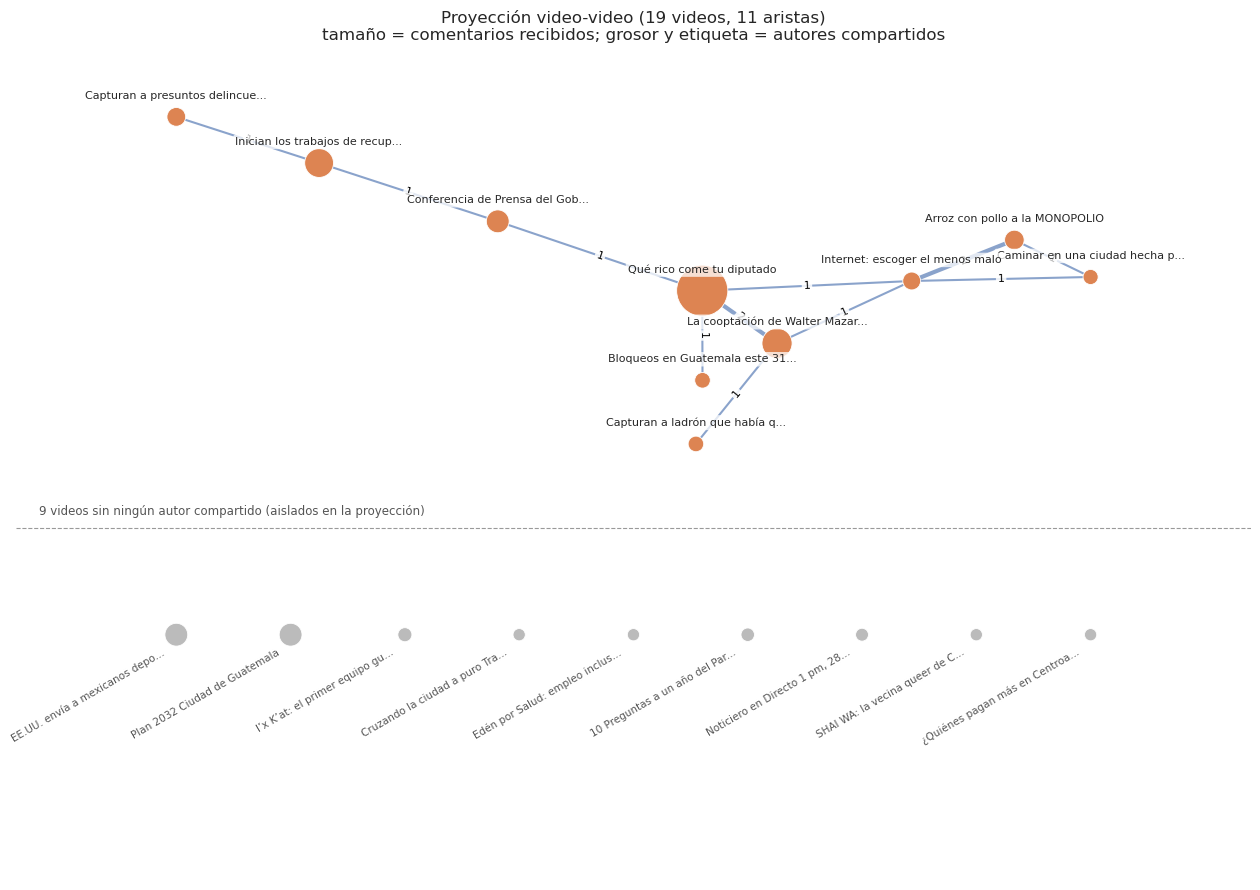

In [8]:
# El layout se calcula sobre la componente conectada para que las 11 aristas sean
# legibles, y los 9 videos sin audiencia compartida se colocan en una fila aparte.
# Ningún nodo ni arista se elimina del dibujo: es una decisión de layout, no de poda.
comp_vv = max(nx.connected_components(VV), key=len)
sub_vv = VV.subgraph(comp_vv)

pos_core = nx.spring_layout(sub_vv, seed=5, k=1.5, iterations=400)
xs = np.array([p[0] for p in pos_core.values()])
ys = np.array([p[1] for p in pos_core.values()])
escalar = lambda a, lo, hi: (a - a.min()) / (a.max() - a.min()) * (hi - lo) + lo
xs, ys = escalar(xs, -1.0, 1.0), escalar(ys, 0.15, 1.35)
pos_vv = {v: (xs[i], ys[i]) for i, v in enumerate(pos_core)}
for i, v in enumerate(videos_aislados):
    pos_vv[v] = (-1.0 + 2.0 * i / (len(videos_aislados) - 1), -0.55)

comentarios_video = comments.groupby('video_id').size()


def recortar(v):
    t = titulo.get(v, v)
    return t if len(t) <= 32 else t[:29] + '...'


fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_edges(VV, pos_vv, width=[1.5 * VV[u][v]['weight'] for u, v in VV.edges()],
                       alpha=0.65, edge_color='#4C72B0', ax=ax)
nx.draw_networkx_nodes(VV, pos_vv, nodelist=list(comp_vv),
                       node_size=[70 + 8 * comentarios_video[v] for v in comp_vv],
                       node_color='#DD8452', linewidths=0.6, edgecolors='white', ax=ax)
nx.draw_networkx_nodes(VV, pos_vv, nodelist=videos_aislados,
                       node_size=[70 + 8 * comentarios_video[v] for v in videos_aislados],
                       node_color='#BBBBBB', linewidths=0.6, edgecolors='white', ax=ax)
nx.draw_networkx_edge_labels(
    VV, pos_vv, edge_labels={(u, v): d['weight'] for u, v, d in VV.edges(data=True)},
    font_size=8, bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85), ax=ax)

for v in comp_vv:
    ax.annotate(recortar(v), pos_vv[v], xytext=(0, 13), textcoords='offset points',
                ha='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))
for v in videos_aislados:
    ax.annotate(recortar(v), pos_vv[v], xytext=(-7, -9), textcoords='offset points',
                ha='right', va='top', fontsize=7.5, rotation=30, color='#555555')

ax.axhline(-0.16, color='#999999', linestyle='--', linewidth=0.8)
ax.text(-1.30, -0.11, f'{len(videos_aislados)} videos sin ningún autor compartido '
                      '(aislados en la proyección)', fontsize=8.5, color='#555555')
ax.set_title(f'Proyección video-video ({VV.number_of_nodes()} videos, {VV.number_of_edges()} aristas)'
             '\ntamaño = comentarios recibidos; grosor y etiqueta = autores compartidos')
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.45, 1.6)
ax.axis('off')
plt.tight_layout()
plt.show()

Las dos figuras muestran el mismo hecho desde ángulos opuestos: en la proyección autor-autor se ven grupos internamente saturados y con muy pocos hilos entre ellos; en la proyección video-video se ve que esos hilos son 11 aristas y que 9 videos quedan sueltos.

# 6. Topología y fragmentación

### 6.1 Nodos, aristas, densidad, grado medio, distribución de grados y componentes

Se calculan las métricas sobre la red bipartita y sobre las dos proyecciones. En la red bipartita la densidad se calcula con la fórmula bipartita (`m / (n_autores × n_videos)`), porque las aristas autor-autor y video-video son imposibles por construcción y la densidad simple las contaría como ausentes.

In [9]:
grados_b = dict(B.degree())
comp_b = sorted(nx.connected_components(B), key=len, reverse=True)

metricas = pd.DataFrame([
    {
        'red': 'bipartita autor-video',
        'nodos': B.number_of_nodes(),
        'aristas': B.number_of_edges(),
        'densidad': round(bipartite.density(B, autores_ids), 4),
        'grado_medio': round(float(np.mean(list(grados_b.values()))), 2),
        'componentes': len(comp_b),
        'componente_mayor': len(comp_b[0]),
        '%_en_mayor': f'{len(comp_b[0]) / B.number_of_nodes():.1%}',
    },
    resumen_red(AA, 'proyección autor-autor'),
    resumen_red(VV, 'proyección video-video'),
])
metricas[['red', 'nodos', 'aristas', 'densidad', 'grado_medio',
          'componentes', 'componente_mayor', '%_en_mayor']]

,red,nodos,aristas,densidad,grado_medio,componentes,componente_mayor,%_en_mayor
0,bipartita autor-video,351,343,0.0544,1.95,10,286,81.5%
1,proyección autor-autor,332,10732,0.1953,64.65,10,276,83.1%
2,proyección video-video,19,11,0.0643,1.16,10,10,52.6%


In [10]:
grado_autores = pd.Series({a: B.degree(a) for a in autores_ids})
grado_videos = pd.Series({v: B.degree(v) for v in videos_ids})

print('Grado en la red bipartita')
print(f'  Autores -> media {grado_autores.mean():.2f} | mediana {grado_autores.median():.0f} | máx {grado_autores.max()}')
print('  Distribución (videos distintos comentados por autor):')
print(grado_autores.value_counts().sort_index().rename('n_autores').to_string())
print(f'\n  Videos  -> media {grado_videos.mean():.2f} | mediana {grado_videos.median():.0f} | máx {grado_videos.max()}')
print(f'  Grados de los 19 videos: {sorted(grado_videos.tolist(), reverse=True)}')

top4 = grado_videos.sort_values(ascending=False).head(4)
print(f'\nLos 4 videos de mayor grado concentran {top4.sum() / B.number_of_edges():.1%} '
      'de las aristas de la red bipartita.')
print(f'Autores con grado 1: {(grado_autores == 1).sum()} ({(grado_autores == 1).mean():.1%})')

Grado en la red bipartita
  Autores -> media 1.03 | mediana 1 | máx 3
  Distribución (videos distintos comentados por autor):
1    323
2      7
3      2

  Videos  -> media 18.05 | mediana 7 | máx 128
  Grados de los 19 videos: [128, 49, 32, 25, 19, 18, 16, 13, 10, 7, 7, 6, 4, 3, 2, 1, 1, 1, 1]

Los 4 videos de mayor grado concentran 68.2% de las aristas de la red bipartita.
Autores con grado 1: 323 (97.3%)


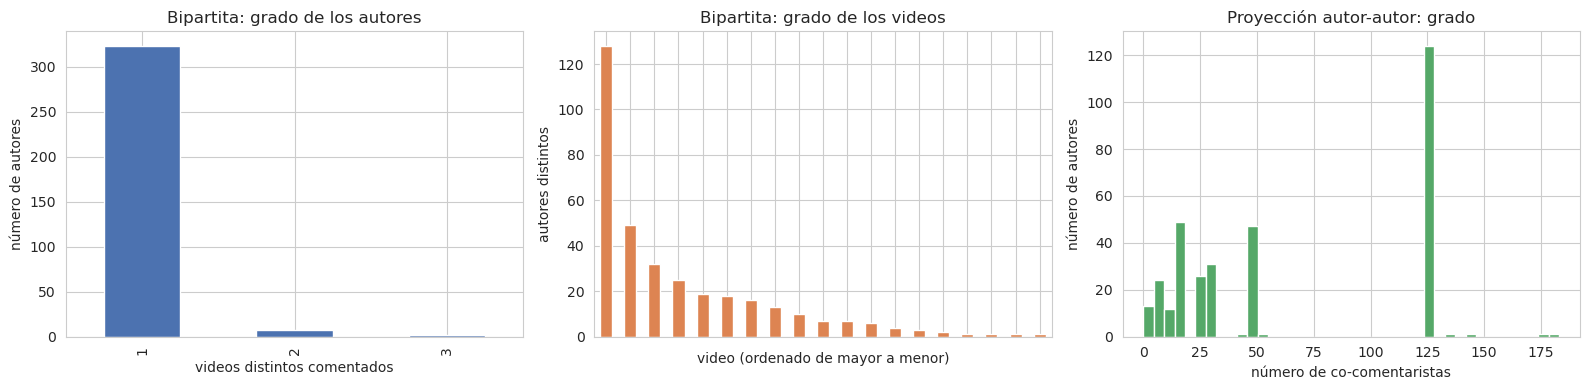

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

grado_autores.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Bipartita: grado de los autores')
axes[0].set_xlabel('videos distintos comentados')
axes[0].set_ylabel('número de autores')

grado_videos.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Bipartita: grado de los videos')
axes[1].set_xlabel('video (ordenado de mayor a menor)')
axes[1].set_ylabel('autores distintos')
axes[1].set_xticklabels([])

pd.Series([g for _, g in AA.degree()]).plot(kind='hist', bins=40, ax=axes[2], color='#55A868')
axes[2].set_title('Proyección autor-autor: grado')
axes[2].set_xlabel('número de co-comentaristas')
axes[2].set_ylabel('número de autores')

plt.tight_layout()
plt.show()

**Lectura de la distribución de grados.** No es una red en la que la mayoría tenga pocas conexiones *y* unos pocos tengan muchas de forma gradual: es una distribución partida en dos, según el tipo de nodo.

- **Autores:** 323 de 332 (97.3 %) tienen grado 1, es decir, comentaron en un solo video. Solo 7 tienen grado 2 y 2 tienen grado 3. El grado máximo de un autor es 3.
- **Videos:** el rango va de 1 a 128 autores. Los 4 videos más comentados concentran el 68.2 % de todas las aristas de la red bipartita.
- En la proyección autor-autor el grado de un autor es básicamente "cuánta gente más comentó en su video", por lo que la distribución reproduce el tamaño de los grupos y no una propiedad individual del autor.

La concentración, entonces, está del lado de los videos, no de las personas. La participación observada es amplia pero superficial: mucha gente que comenta una sola vez, en unos pocos videos.

### 6.2 Cohesión y transitividad

In [12]:
gc_b = B.subgraph(comp_b[0]).copy()
gc_aa = AA.subgraph(max(nx.connected_components(AA), key=len)).copy()
gc_vv = VV.subgraph(max(nx.connected_components(VV), key=len)).copy()


def fila_cohesion(nombre, G, gc, clustering):
    return {
        'red': nombre,
        'transitividad': round(nx.transitivity(G), 4),
        'clustering_medio': round(clustering, 4),
        'nodos_comp_mayor': gc.number_of_nodes(),
        'aristas_comp_mayor': gc.number_of_edges(),
        'conectividad_nodos': nx.node_connectivity(gc),
        'conectividad_aristas': nx.edge_connectivity(gc),
        'puntos_articulación': len(list(nx.articulation_points(gc))),
    }


cohesion = pd.DataFrame([
    fila_cohesion('bipartita autor-video', B, gc_b, bipartite.average_clustering(B)),
    fila_cohesion('proyección autor-autor', AA, gc_aa, nx.average_clustering(AA)),
    fila_cohesion('proyección video-video', VV, gc_vv, nx.average_clustering(VV)),
])
cohesion

,red,transitividad,clustering_medio,nodos_comp_mayor,aristas_comp_mayor,conectividad_nodos,conectividad_aristas,puntos_articulación
0,bipartita autor-video,0.0000,0.8920,286,287,1,1,17
1,proyección autor-autor,0.9840,0.9720,276,10269,1,5,7
2,proyección video-video,0.3158,0.1491,10,11,1,1,5


In [13]:
# Prueba directa de fragilidad: qué queda de la conectividad sin los autores multi-video.
autores_puente = grado_autores[grado_autores > 1].index.tolist()
AA_sin_puentes = AA.copy()
AA_sin_puentes.remove_nodes_from(autores_puente)
comp_sin = sorted(nx.connected_components(AA_sin_puentes), key=len, reverse=True)

print(f'Autores con grado > 1 (puentes potenciales): {len(autores_puente)} de {len(autores_ids)} '
      f'({len(autores_puente) / len(autores_ids):.1%})')
print(f'Componente mayor autor-autor CON esos autores:  {gc_aa.number_of_nodes()} nodos')
print(f'Componente mayor autor-autor SIN esos autores:  {len(comp_sin[0])} nodos '
      f'({len(comp_sin)} componentes en total)')

Autores con grado > 1 (puentes potenciales): 9 de 332 (2.7%)
Componente mayor autor-autor CON esos autores:  276 nodos
Componente mayor autor-autor SIN esos autores:  124 nodos (19 componentes en total)


**Interpretación.**

- La **transitividad de la red bipartita es 0** por construcción: un triángulo exigiría una arista autor-autor o video-video, imposibles en una red de dos modos. El valor no indica ausencia de cohesión, indica que la medida no aplica. Por eso se reporta además el coeficiente de agrupamiento bipartito (0.892), que sí está definido para dos modos y mide cuánto se solapan los vecindarios.
- La **transitividad de la proyección autor-autor es 0.984**, prácticamente 1. Leerlo como "comunidad muy cohesionada" sería un error: es la firma matemática de una unión de grupos casi completos. Los únicos triángulos incompletos aparecen alrededor de los 9 autores que comentaron en más de un video.
- La **proyección video-video** tiene transitividad 0.316 y agrupamiento medio 0.149, valores bajos: los videos se enlazan en cadenas, no en bloques.
- La **cohesión es mínima**: la conectividad de nodos es 1 en las tres redes, así que basta eliminar un solo nodo bien elegido para partir la componente mayor. En la bipartita y en la video-video basta incluso con una sola arista (conectividad de aristas 1); en la proyección autor-autor ese valor sube a 5 únicamente porque cortar a un autor puente exige cortar todas las aristas que lo unen a su grupo. La componente mayor de la red bipartita tiene 286 nodos y 287 aristas, es decir, apenas una arista más que un árbol, y contiene 17 puntos de articulación.
- La prueba directa está en la última celda: al retirar los 9 autores multi-video (2.7 % del total), la componente mayor de la proyección autor-autor cae de 276 a 124 autores y la proyección pasa de 10 a 19 componentes. Toda la conectividad entre grupos descansa en esos 9 nodos.

### 6.3 Nodos periféricos y aislados

Es necesario separar dos situaciones que se ven igual en un gráfico pero significan cosas distintas: **aislamiento observado** (el nodo está en la red y no comparte audiencia con nadie) y **ausencia de datos** (el nodo no llegó a la red porque no se recolectaron sus comentarios).

In [14]:
print('--- AISLAMIENTO OBSERVADO ---')
autores_aislados_aa = list(nx.isolates(AA))
print(f'Autores aislados en la proyección autor-autor: {len(autores_aislados_aa)}')
for a in autores_aislados_aa:
    vid = video_principal[a]
    print(f'  {nombre_autor[a][:28]:<30} único comentarista de: {titulo.get(vid, vid)[:45]}')

print(f'\nVideos aislados en la proyección video-video: {len(videos_aislados)} de {len(videos_ids)}')
print(f'Autores periféricos (grado 1 en la bipartita): {(grado_autores == 1).sum()} '
      f'({(grado_autores == 1).mean():.1%})')

print('\nComponentes de la red bipartita:')
set_videos = set(videos_ids)
for i, comp in enumerate(comp_b, 1):
    vids = [n for n in comp if n in set_videos]
    print(f'  Componente {i}: {len(comp):>3} nodos = {len(vids)} video(s) + {len(comp) - len(vids)} autores')

--- AISLAMIENTO OBSERVADO ---
Autores aislados en la proyección autor-autor: 4
  @elizabethmonterroso7719       único comentarista de: Cruzando la ciudad a puro Transmetro
  @elioelias7267                 único comentarista de: Edén por Salud: empleo inclusivo para persona
  @aditalissethevasquezrojas80   único comentarista de: SHAI WA: la vecina queer de Casa Presidencial
  @jahirdiaz5862                 único comentarista de: ¿Quiénes pagan más en Centroamérica?

Videos aislados en la proyección video-video: 9 de 19
Autores periféricos (grado 1 en la bipartita): 323 (97.3%)

Componentes de la red bipartita:
  Componente 1: 286 nodos = 10 video(s) + 276 autores
  Componente 2:  26 nodos = 1 video(s) + 25 autores
  Componente 3:  19 nodos = 1 video(s) + 18 autores
  Componente 4:   5 nodos = 1 video(s) + 4 autores
  Componente 5:   4 nodos = 1 video(s) + 3 autores
  Componente 6:   3 nodos = 1 video(s) + 2 autores
  Componente 7:   2 nodos = 1 video(s) + 1 autores
  Componente 8:   2 n

In [15]:
print('--- AUSENCIA DE DATOS ---')
videos_sin_comentarios = len(videos) - len(videos_ids)
print(f'Videos del catálogo: {len(videos)}')
print(f'Videos con al menos un comentario recolectado: {len(videos_ids)}')
print(f'Videos que NO entran a la red: {videos_sin_comentarios} ({videos_sin_comentarios / len(videos):.1%})')
print('\nEstos videos no son nodos aislados: no son nodos. No se observó que carecieran')
print('de participación, sino que no se recolectaron comentarios para ellos.')
print('\nCanales de los 19 videos que sí tienen comentarios:')
print(videos[videos['video_id'].isin(videos_ids)]['channel_name'].value_counts().to_string())

--- AUSENCIA DE DATOS ---
Videos del catálogo: 293
Videos con al menos un comentario recolectado: 19
Videos que NO entran a la red: 274 (93.5%)

Estos videos no son nodos aislados: no son nodos. No se observó que carecieran
de participación, sino que no se recolectaron comentarios para ellos.

Canales de los 19 videos que sí tienen comentarios:
channel_name
Quorum                                   11
Gobierno de la República de Guatemala     2
Noticiero Guatevisión 13 Hrs.             1
Noti7                                     1
Noticias Telemundo                        1
PrensaLibreOficial                        1
TN23 Guatemala                            1
Municipalidad de Guatemala                1


**Distinción explícita.**

- **Aislamiento observado.** 4 autores quedan aislados en la proyección autor-autor: fueron los únicos comentaristas del video en el que participaron, de modo que no comparten audiencia con nadie *dentro de los datos disponibles*. Igualmente, 9 de los 19 videos comentados no comparten ni un autor con otro video. Además, la red bipartita se fragmenta en 10 componentes: una de 286 nodos (10 videos) y nueve pequeñas de 2 a 26 nodos, cada una organizada alrededor de un solo video.
- **Ausencia de datos.** 274 de los 293 videos del catálogo (93.5 %) no aparecen en ninguna red. No son nodos periféricos ni aislados: simplemente no son nodos. Afirmar que "no tienen participación" sería una inferencia no soportada; lo único observado es que no se recolectaron comentarios para ellos.
- Del mismo modo, un autor con grado 1 no es necesariamente una persona poco participativa: puede haber comentado en muchos videos fuera de la muestra. Su grado describe la muestra, no su comportamiento en YouTube.
- La cobertura también está sesgada por canal: 11 de los 19 videos comentados son del canal Quorum, así que la componente mayor refleja en buena medida la audiencia de un solo canal.

### 6.4 Hallazgos derivados del análisis estructural

1. **La red es una colección de audiencias separadas, no una comunidad única.** Las tres redes se fragmentan en 10 componentes. En la bipartita, la componente mayor agrupa el 81.5 % de los nodos pero se organiza alrededor de apenas 10 de los 19 videos; las nueve componentes restantes son videos con su público propio, sin ningún contacto con el resto.

2. **La concentración está en los videos, no en las personas.** El grado máximo de un autor es 3 y el 97.3 % tiene grado 1, mientras que los videos van de 1 a 128 comentaristas y los 4 mayores concentran el 68.2 % de las aristas. La estructura la fija el contenido que atrae comentarios, no usuarios especialmente activos.

3. **La conectividad depende de 9 personas.** Los 9 autores que comentaron en más de un video son los únicos que unen grupos. Al retirarlos, la componente mayor de la proyección autor-autor cae de 276 a 124 autores y la red pasa de 10 a 19 componentes. Con conectividad de nodos igual a 1 y 17 puntos de articulación en la componente mayor bipartita, la estructura es máximamente frágil: un árbol de "abanicos" con un solo ciclo adicional.

4. **La alta densidad y transitividad de la proyección autor-autor no son evidencia de cohesión social.** Densidad 0.195 y transitividad 0.984 son la consecuencia mecánica de convertir cada video en un grupo casi completo; un solo video aporta el 76 % de las aristas. La medida honesta del solapamiento de audiencia es la proyección video-video: 11 aristas, densidad 0.064 y casi todos los pesos iguales a 1.

5. **Estos resultados describen la muestra recolectada.** La fragmentación observada es compatible con dos explicaciones que los datos no permiten separar: audiencias realmente disjuntas, o una recolección que capturó pocos comentarios por video y solo 19 videos de 293. Las secciones siguientes trabajan sobre esta misma estructura, de modo que la limitación se arrastra a la detección de comunidades y a las medidas de centralidad.

### Exportación para las siguientes secciones del laboratorio

In [16]:
df_aa = pd.DataFrame([{"source": u, "target": v, "weight": d["weight"]} for u, v, d in AA.edges(data=True)])
df_vv = pd.DataFrame([{"source": u, "target": v, "weight": d["weight"]} for u, v, d in VV.edges(data=True)])
df_aa.to_csv(DATA_DIR / "proj_autor_autor.csv", index=False, encoding="utf-8-sig")
df_vv.to_csv(DATA_DIR / "proj_video_video.csv", index=False, encoding="utf-8-sig")
print(f"Guardado: {DATA_DIR}/proj_autor_autor.csv ({len(df_aa)} aristas)")
print(f"Guardado: {DATA_DIR}/proj_video_video.csv ({len(df_vv)} aristas)")

Guardado: ../data/proj_autor_autor.csv (10732 aristas)
Guardado: ../data/proj_video_video.csv (11 aristas)
